In [ ]:
# Google Drive 마운트
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
# 필요한 라이브러리 임포트
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

import pandas as pd
import numpy as np
import os
import glob
from PIL import Image
import shutil
import cv2
from tqdm import tqdm  # tqdm import

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [54]:
# 디바이스 선택: GPU가 사용 가능하면 'cuda', 그렇지 않으면 'cpu'를 사용하여 모델 학습
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

# MISSION 1-1

In [29]:
# 이미지 디렉토리 설정
train_image_dir = 'raw_data/training_image'
valid_image_dir = 'raw_data/validation_image'

In [30]:
# 파일 이름에서 성별과 스타일을 추출하는 함수
def extract_info_from_filename(filename):
    # 파일 이름에서 확장자를 제거
    file_name_without_ext = os.path.splitext(filename)[0]

    # 파일 이름을 '_'로 구분
    parts = file_name_without_ext.split('_')

    # 성별은 마지막 부분에 위치
    gender = parts[-1]

    # 스타일은 성별 바로 앞 부분
    style = parts[-2]

    return gender, style

In [31]:
# 주어진 디렉토리의 파일 목록을 처리하여 성별과 스타일별 집계를 생성하는 함수
def process_image_directory(image_dir):
    file_list = os.listdir(image_dir)
    data = []

    for file_name in file_list:
        if file_name.endswith('.jpg'):
            gender, style = extract_info_from_filename(file_name)
            # 성별 값 변환
            gender_name = '여성' if gender == 'W' else '남성'
            data.append({'성별': gender_name, '스타일': style, '이미지 수': 1})

    df = pd.DataFrame(data)
    # 성별과 스타일별로 그룹화하여 이미지 수 계산
    gender_style_count = df.groupby(['성별', '스타일']).size().reset_index(name='이미지 수')

    return gender_style_count

In [32]:
# Training 이미지 데이터 처리
train_table = process_image_directory(train_image_dir)
train_table

,성별,스타일,이미지 수
0,남성,bold,268
1,남성,hiphop,274
2,남성,hippie,260
3,남성,ivy,237
4,남성,metrosexual,278
5,남성,mods,269
6,남성,normcore,364
7,남성,sportivecasual,298
8,여성,athleisure,67
9,여성,bodyconscious,95


In [6]:
# Validation 이미지 데이터 처리
valid_table = process_image_directory(valid_image_dir)
valid_table

,성별,스타일,이미지 수
0,남성,bold,57
1,남성,hiphop,66
2,남성,hippie,82
3,남성,ivy,79
4,남성,metrosexual,58
5,남성,mods,80
6,남성,normcore,51
7,남성,sportivecasual,52
8,여성,athleisure,14
9,여성,bodyconscious,23


# MISSION 1-2

## 클래스 별 폴더 만들기 : dataclass

In [ ]:
# 기본 디렉토리 설정
train_image_dir = '/content/drive/MyDrive/data/training_image'  # 원본 이미지 디렉토리 경로
train_target_dir = '/content/drive/MyDrive/data/data_class/training'  # 클래스 폴더 디렉토리 경로

# 성별_스타일 클래스 폴더 생성 및 이미지 복사
for index, row in train_table.iterrows():
    class_name = f"{row['Gender']}_{row['Style']}"
    class_folder = os.path.join(train_target_dir, class_name)

    # 클래스 폴더가 없으면 생성
    os.makedirs(class_folder, exist_ok=True)

    # 해당 클래스에 맞는 이미지 복사
    for filename in os.listdir(train_image_dir):
        if filename.endswith(".jpg"):
            parts = filename[:-4].split('_')
            if len(parts) >= 5:
                gender = parts[4]
                style = parts[3]

                # 성별과 스타일이 일치하면 파일 복사
                if gender == row['Gender'] and style == row['Style']:
                    src_path = os.path.join(train_image_dir, filename)
                    dst_path = os.path.join(class_folder, filename)
                    shutil.copyfile(src_path, dst_path)
                    print(f"Copied {filename} to {class_folder}")

In [ ]:
# 기본 디렉토리 설정
valid_image_dir = '/content/drive/MyDrive/data/validation_image'  # 원본 이미지 디렉토리 경로
valid_target_dir = '/content/drive/MyDrive/data/data_class/validation'  # 클래스 폴더 디렉토리 경로

# 성별_스타일 클래스 폴더 생성 및 이미지 복사
for index, row in valid_table.iterrows():
    class_name = f"{row['Gender']}_{row['Style']}"
    class_folder = os.path.join(valid_target_dir, class_name)

    # 클래스 폴더가 없으면 생성
    os.makedirs(class_folder, exist_ok=True)

    # 해당 클래스에 맞는 이미지 복사
    for filename in os.listdir(valid_image_dir):
        if filename.endswith(".jpg"):  # 확장자 확인 (필요에 따라 조정)
            parts = filename[:-4].split('_')
            if len(parts) >= 5:
                gender = parts[4]
                style = parts[3]

                # 성별과 스타일이 일치하면 파일 복사
                if gender == row['Gender'] and style == row['Style']:
                    src_path = os.path.join(valid_image_dir, filename)
                    dst_path = os.path.join(class_folder, filename)
                    shutil.copyfile(src_path, dst_path)
                    print(f"Copied {filename} to {class_folder}")

## yolo를 활용한 detect crop 폴더 만들기

In [2]:
# YOLOv5 클론 및 이동
!git clone https://github.com/ultralytics/yolov5
%cd yolov5

# 종속성 설치
!pip install -qr requirements.txt comet_ml

C:\Users\juril\데이터크리에이터캠프\yolov5


Cloning into 'yolov5'...


In [12]:
import torch
import utils

display = utils.notebook_init()  #  모델 훈련을 위한 초기 환경을 설정

YOLOv5  v7.0-386-g81ac034a Python-3.12.4 torch-2.5.1+cpu CPU


Setup complete  (8 CPUs, 15.7 GB RAM, 217.7/475.7 GB disk)


In [6]:
print(os.getcwd())

C:\Users\juril\데이터크리에이터캠프\yolov5


In [15]:
# YOLOv5 모델 로드 (이미 YOLOv5가 설치되어 있다고 가정)
model = torch.hub.load('ultralytics/yolov5', 'yolov5s')  # 'yolov5s'는 작은 모델

def detect_largest_person(input_folder, output_folder):
    subfolders = glob.glob(os.path.join(input_folder, '*'))  # 각 폴더의 경로 리스트
    
    for folder in tqdm(subfolders, desc="Processing styles"):  # tqdm 적용 (스타일별 진행 상황 표시)
        style = os.path.basename(folder)  # 폴더 이름 (스타일 이름) 추출
        os.makedirs(os.path.join(output_folder, style), exist_ok=True)  # 스타일 이름에 해당하는 결과 폴더 생성

        images = glob.glob(os.path.join(folder, '*.jpg'))  # 각 스타일 폴더 내의 이미지들

        for img_path in images:
            img = cv2.imread(img_path)  # 이미지 읽기

            # YOLO 모델을 이용한 객체 검출
            results = model(img)  # 이미지에서 객체 검출
            detections = results.pred[0]  # 검출된 객체 리스트 (배경 제외)

            # 사람(클래스 ID 0)만 필터링
            person_detections = detections[detections[:, 5] == 0]  # 클래스 ID 0은 사람

            if person_detections.size(0) > 0:
                # 사람 객체들 중 가장 큰 객체 선택 (면적 기준)
                largest_person = None
                max_area = 0
                for det in person_detections:
                    x1, y1, x2, y2 = det[:4]  # 객체의 Bounding Box
                    area = (x2 - x1) * (y2 - y1)  # 면적 계산

                    if area > max_area:
                        max_area = area
                        largest_person = det

                if largest_person is not None:
                    x1, y1, x2, y2 = largest_person[:4]
                    cropped_img = img[int(y1):int(y2), int(x1):int(x2)]  # 가장 큰 사람 객체만 크롭

                    # 결과 저장
                    output_path = os.path.join(output_folder, style, os.path.basename(img_path))
                    cv2.imwrite(output_path, cropped_img)  # 크롭된 이미지 저장

    print("검출 및 크롭 작업이 완료되었습니다!")

Using cache found in C:\Users\juril/.cache\torch\hub\ultralytics_yolov5_master
YOLOv5  v7.0-386-g81ac034a Python-3.12.4 torch-2.5.1+cpu CPU

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


In [16]:
# 입력 폴더와 출력 폴더 설정
train_input_folder = 'C:/Users/juril/데이터크리에이터캠프/data_class/training_image'
train_output_folder = 'C:/Users/juril/데이터크리에이터캠프/detected_output/training_image'

# 함수 호출
detect_largest_person(train_input_folder, train_output_folder)

Processing styles: 100%|████████████████████████████████████████████████████████████| 31/31 [1:01:00<00:00, 118.07s/it]

검출 및 크롭 작업이 완료되었습니다!


In [17]:
# 입력 폴더와 출력 폴더 설정
valid_input_folder = 'C:/Users/juril/데이터크리에이터캠프/data_class/validation_image'
valid_output_folder = 'C:/Users/juril/데이터크리에이터캠프/detected_output/validation_image'

# 함수 호출
detect_largest_person(valid_input_folder, valid_output_folder)

Processing styles: 100%|███████████████████████████████████████████████████████████████| 31/31 [08:05<00:00, 15.68s/it]

검출 및 크롭 작업이 완료되었습니다!


## detection 안 된 이미지 찾기

In [2]:
def count_image_and_find_missing(data, crop_data):
    # data와 crop_data의 파일명을 저장할 딕셔너리
    data_files_by_class = {}
    crop_data_files_by_class = {}
    missing_files_by_class = {}  # 클래스별 누락 파일 저장
    
    # data 폴더 내 모든 클래스별 이미지 파일 이름 수집
    for class_folder in os.listdir(data):
        class_folder_path = os.path.join(data, class_folder)
        if os.path.isdir(class_folder_path):
            data_files_by_class[class_folder] = set(
                file for file in os.listdir(class_folder_path) if file.endswith('.jpg')
            )
    
    # crop_data 폴더 내 모든 클래스별 이미지 파일 이름 수집
    for class_folder in os.listdir(crop_data):
        class_folder_path = os.path.join(crop_data, class_folder)
        if os.path.isdir(class_folder_path):
            crop_data_files_by_class[class_folder] = set(
                file for file in os.listdir(class_folder_path) if file.endswith('.jpg')
            )
    
    # 클래스별 누락 파일 계산
    for class_name, files_in_data in data_files_by_class.items():
        files_in_crop_data = crop_data_files_by_class.get(class_name, set())
        missing_files = files_in_data - files_in_crop_data
        missing_files_by_class[class_name] = missing_files
    
    # 누락된 파일 출력
    total_missing_files = 0
    for class_name, missing_files in missing_files_by_class.items():
        if missing_files:  # 누락된 파일이 있는 경우만 출력
            print(f"{class_name}: Missing files = {len(missing_files)}")
            print(f"  Missing files: {missing_files}")
            total_missing_files += len(missing_files)
    
    # 총 누락 파일 개수 출력
    print(f"\nTotal missing files: {total_missing_files}")

In [16]:
# 데이터 파일 경로 설정 (이미지 폴더 지정)
train_image = 'C:/Users/juril/데이터크리에이터캠프/data_class/training_image'
crop_train_image = 'C:/Users/juril/데이터크리에이터캠프/detected_output/training_image'
count_image_and_find_missing(train_image, crop_train_image)

M_bold: Missing files = 13
  Missing files: {'W_32390_80_bold_M.jpg', 'W_12142_80_bold_M.jpg', 'W_26019_80_bold_M.jpg', 'W_53446_80_bold_M.jpg', 'W_17663_80_bold_M.jpg', 'W_26631_80_bold_M.jpg', 'W_24690_80_bold_M.jpg', 'W_16085_80_bold_M.jpg', 'W_17444_80_bold_M.jpg', 'W_11014_80_bold_M.jpg', 'W_12128_80_bold_M.jpg', 'W_12383_80_bold_M.jpg', 'W_15159_80_bold_M.jpg'}
M_hiphop: Missing files = 7
  Missing files: {'W_04309_90_hiphop_M.jpg', 'W_17365_90_hiphop_M.jpg', 'W_01615_90_hiphop_M.jpg', 'W_04319_90_hiphop_M.jpg', 'W_23971_90_hiphop_M.jpg', 'W_11033_90_hiphop_M.jpg', 'W_55820_90_hiphop_M.jpg'}
M_hippie: Missing files = 14
  Missing files: {'W_15593_70_hippie_M.jpg', 'W_24243_70_hippie_M.jpg', 'W_24543_70_hippie_M.jpg', 'W_15740_70_hippie_M.jpg', 'W_15503_70_hippie_M.jpg', 'W_15438_70_hippie_M.jpg', 'W_26324_70_hippie_M.jpg', 'W_16677_70_hippie_M.jpg', 'W_15443_70_hippie_M.jpg', 'W_12298_70_hippie_M.jpg', 'W_24352_70_hippie_M.jpg', 'W_15465_70_hippie_M.jpg', 'W_15587_70_hippie_M.jpg

In [17]:
valid_image = 'C:/Users/juril/데이터크리에이터캠프/data_class/validation_image'
crop_valid_image = 'C:/Users/juril/데이터크리에이터캠프/detected_output/validation_image'
count_image_and_find_missing(valid_image, crop_valid_image)

M_bold: Missing files = 3
  Missing files: {'W_24598_80_bold_M.jpg', 'W_12128_80_bold_M.jpg', 'W_53446_80_bold_M.jpg'}
M_hiphop: Missing files = 1
  Missing files: {'W_23971_90_hiphop_M.jpg'}
M_hippie: Missing files = 5
  Missing files: {'W_24543_70_hippie_M.jpg', 'W_15740_70_hippie_M.jpg', 'W_15503_70_hippie_M.jpg', 'W_12298_70_hippie_M.jpg', 'W_26324_70_hippie_M.jpg'}
M_mods: Missing files = 1
  Missing files: {'W_15341_60_mods_M.jpg'}
M_normcore: Missing files = 1
  Missing files: {'W_24556_19_normcore_M.jpg'}
W_bodyconscious: Missing files = 1
  Missing files: {'W_11509_80_bodyconscious_W.jpg'}
W_ecology: Missing files = 1
  Missing files: {'W_11423_00_ecology_W.jpg'}
W_grunge: Missing files = 1
  Missing files: {'W_00359_90_grunge_W.jpg'}
W_hippie: Missing files = 2
  Missing files: {'W_30671_70_hippie_W.jpg', 'W_07532_70_hippie_W.jpg'}
W_kitsch: Missing files = 2
  Missing files: {'W_44232_90_kitsch_W.jpg', 'W_18095_90_kitsch_W.jpg'}
W_normcore: Missing files = 1
  Missing files:

## 수작업으로 crop한 이미지 추가 한 후 결과 확인

In [12]:
# 데이터 파일 경로 설정 (이미지 폴더 지정)
train_image = 'C:/Users/juril/데이터크리에이터캠프/data_class/training_image'
crop_train_image = 'C:/Users/juril/데이터크리에이터캠프/detected_output/training_image'
count_image_and_find_missing(train_image, crop_train_image)


Total missing files: 0


In [49]:
valid_image = 'C:/Users/juril/데이터크리에이터캠프/data_class/validation_image'
crop_valid_image = 'C:/Users/juril/데이터크리에이터캠프/detected_output/validation_image'
count_image_and_find_missing(valid_image, crop_valid_image)


Total missing files: 0


In [35]:
def count_images_in_crop_data(crop_data):
    class_image_counts = {}  # 클래스별 이미지 개수 저장
    total_images = 0  # 총 이미지 수
    
    # crop_data 폴더 내 모든 클래스별 이미지 파일 개수 계산
    for class_folder in os.listdir(crop_data):
        class_folder_path = os.path.join(crop_data, class_folder)
        if os.path.isdir(class_folder_path):
            # 해당 클래스 폴더에 있는 .jpg 파일 개수
            image_count = len([file for file in os.listdir(class_folder_path) if file.endswith('.jpg')])
            class_image_counts[class_folder] = image_count
            total_images += image_count
    
    # 클래스별 이미지 개수 출력
    for class_name, count in class_image_counts.items():
        print(f"{class_name}: {count}")
    
    # 총 이미지 개수 출력
    print(f"\nTotal images in crop_data: {total_images}")

In [36]:
count_images_in_crop_data(crop_train_image)

M_bold: 268
M_hiphop: 274
M_hippie: 260
M_ivy: 237
M_metrosexual: 278
M_mods: 269
M_normcore: 364
M_sportivecasual: 298
W_athleisure: 67
W_bodyconscious: 95
W_cityglam: 67
W_classic: 77
W_disco: 37
W_ecology: 64
W_feminine: 154
W_genderless: 77
W_grunge: 31
W_hiphop: 48
W_hippie: 91
W_kitsch: 91
W_lingerie: 55
W_lounge: 45
W_military: 33
W_minimal: 139
W_normcore: 153
W_oriental: 78
W_popart: 41
W_powersuit: 120
W_punk: 65
W_space: 37
W_sportivecasual: 157

Total images in crop_data: 4070


In [50]:
count_images_in_crop_data(crop_valid_image)

M_bold: 57
M_hiphop: 66
M_hippie: 82
M_ivy: 79
M_metrosexual: 58
M_mods: 80
M_normcore: 51
M_sportivecasual: 52
W_athleisure: 14
W_bodyconscious: 23
W_cityglam: 18
W_classic: 22
W_disco: 10
W_ecology: 17
W_feminine: 44
W_genderless: 12
W_grunge: 10
W_hiphop: 8
W_hippie: 14
W_kitsch: 22
W_lingerie: 5
W_lounge: 8
W_military: 9
W_minimal: 35
W_normcore: 20
W_oriental: 18
W_popart: 8
W_powersuit: 34
W_punk: 12
W_space: 15
W_sportivecasual: 48

Total images in crop_data: 951


## 모델 생성

In [55]:
crop_train_image = 'C:/Users/juril/데이터크리에이터캠프/detected_output/training_image'
crop_valid_image = 'C:/Users/juril/데이터크리에이터캠프/detected_output/validation_image'

In [56]:
# 하이퍼파라미터 설정
batch_size = 32       # 배치 크기: 32로 설정한 이유는 메모리 효율성과 학습 안정성의 균형을 맞추기 위함입니다.일반적으로 32~64 사이가 많이 쓰입니다.
learning_rate = 0.001 # 0.001은 Adam 옵티마이저에서 많이 사용되는 기본 학습률로, 안정적인 수렴을 보이는 경우가 많아 초기 값으로 적합합니다.
epochs = 200          # 데이터가 충분하고 모델이 잘 학습되는 경우에 일반적으로 수십에서 수백 사이가 적합합니다.
patience = 20         # Early Stopping을 위한 patience: 연속적으로 검증 손실이 개선되지 않는 경우 학습을 중단하기 위한 기준입니다.
# 20회 연속으로 개선되지 않으면 중단하며, 이 수치는 모델이 최적화되지 않는 상황을 방지하는 데 유용합니다.

training image set의 평균, 표준편차 계산

In [62]:
# ToTensor와 Resize 변환을 함께 적용
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # 모든 이미지를 224x224로 변환
    transforms.ToTensor()
])

# 데이터셋 로드
dataset_train = datasets.ImageFolder(root=crop_train_image, transform=transform)

# DataLoader 생성
data_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=False, num_workers=4)

# 평균과 표준편차 계산 초기화
mean = torch.zeros(3)  # 3채널(RGB) 평균
squared_sum = torch.zeros(3)  # 3채널 제곱합
total_pixels = 0  # 총 픽셀 수

# tqdm을 사용한 진행 표시
for images, _ in tqdm(data_loader, desc="Calculating Mean and Std"):
    # 배치 크기 및 이미지 픽셀 크기 가져오기
    batch_size, channels, height, width = images.shape
    pixels = batch_size * height * width  # 배치 내 총 픽셀 수
    total_pixels += pixels

    # 배치 평균 및 제곱합 누적
    mean += images.sum(dim=[0, 2, 3])  # 채널별 합산
    squared_sum += (images ** 2).sum(dim=[0, 2, 3])  # 채널별 제곱합

# 평균 계산
mean /= total_pixels

# 분산과 표준편차 계산
var = (squared_sum / total_pixels) - (mean ** 2)  # 분산
std = torch.sqrt(var)  # 표준편차

print("Calculated Mean:", mean)
print("Calculated Std:", std)

Calculating Mean and Std: 100%|██████████████████████████████████████████████████████| 128/128 [02:44<00:00,  1.29s/it]

Calculated Mean: tensor([0.4777, 0.4408, 0.4262])
Calculated Std: tensor([0.3155, 0.3017, 0.3021])


* 평균: [0.4777, 0.4408, 0.4262]
* 표준편차: [0.3155, 0.3017, 0.3021]

In [63]:
# 데이터 증강 및 정규화 설정 (학습과 검증에 다른 변환을 적용)
# 학습 데이터 변환: 다양한 증강 기법을 사용하여 모델이 다양한 이미지 변형에 잘 적응할 수 있도록 함
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),     # 이미지를 ResNet 모델의 표준 입력 크기인 224x224로 변환
    transforms.RandomHorizontalFlip(), # 수평 반전은 이미지에 방향성이 없는 경우 좋은 데이터 증강 기법입니다.
    transforms.RandomRotation(15),     # 15도 내외의 회전을 통해 모델이 회전 변형에 대해 학습할 수 있도록 합니다.
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # 랜덤 크롭 및 리사이즈로 다양한 배경을 학습하게 함
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # 색조 변형을 통해 다양한 색상을 학습
    transforms.ToTensor(),       # 데이터를 텐서 형식으로 변환하여 모델에 입력할 수 있도록 함
    transforms.Normalize(mean=mean.tolist(), std=std.tolist()) # 평균 및 표준편차로 정규화
])
# 검증 데이터 변환: 테스트 이미지와 같은 정규화만 적용하여 모델 성능 평가
transform_valid = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist())
])

In [65]:
# 데이터셋 로드
train_dataset = datasets.ImageFolder(root=crop_train_image, transform=transform_train)
valid_dataset = datasets.ImageFolder(root=crop_valid_image, transform=transform_valid)

In [66]:
# 데이터 로더 생성
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(dataset=valid_dataset, batch_size=batch_size, shuffle=False)

In [67]:
import torchvision.models as models
import torch.nn as nn

# 가중치 없이 ResNet-18 모델 생성
model = models.resnet18(weights=None)

# 출력층을 31개 클래스로 변경
model.fc = nn.Linear(model.fc.in_features, 31)

# 모델 확인
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [68]:
# 손실 함수와 옵티마이저 정의
criterion = nn.CrossEntropyLoss() # 다중 클래스 분류에 적합한 CrossEntropy 손실 함수 사용
optimizer = optim.Adam(model.parameters(), lr=learning_rate) # Adam 옵티마이저는 학습률 조정이 자동으로 이뤄져 수렴에 효과적입니다.
# 학습률 조정이 잘 되며 모멘텀과 RMSprop의 장점을 결합하여 빠르고 안정적으로 수렴합니다.

## 모델 학습

In [69]:
# 학습과 검증 반복문 (Early Stopping 적용)
train_losses, valid_losses = [], []
train_accuracies, valid_accuracies = [], []
best_valid_loss = float('inf')
early_stop_count = 0

In [70]:
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [71]:
for epoch in range(epochs):
    model.train()
    running_loss, correct = 0.0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / len(train_loader.dataset)
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # 검증 모드로 전환하여 모델 성능 평가
    model.eval()
    running_loss, correct = 0.0, 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()

    # 에포크 당 평균 검증 손실 및 정확도 계산
    valid_loss = running_loss / len(valid_loader)
    valid_accuracy = correct / len(valid_loader.dataset)
    valid_losses.append(valid_loss)
    valid_accuracies.append(valid_accuracy)

    # 학습 및 검증 손실, 정확도 출력
    print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, \
Valid Loss: {valid_loss:.4f}, Valid Acc: {valid_accuracy:.4f}')


    # Early Stopping 조건 확인
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        early_stop_count = 0
    else:
        early_stop_count += 1
        if early_stop_count >= patience:
            print("Early stopping triggered")
            break

Epoch 1/200, Train Loss: 3.3633, Train Acc: 0.0698, Valid Loss: 4.2628, Valid Acc: 0.0557
Epoch 2/200, Train Loss: 3.2366, Train Acc: 0.0799, Valid Loss: 3.1949, Valid Acc: 0.0778
Epoch 3/200, Train Loss: 3.2109, Train Acc: 0.0774, Valid Loss: 3.2328, Valid Acc: 0.0778
Epoch 4/200, Train Loss: 3.1916, Train Acc: 0.0813, Valid Loss: 3.1777, Valid Acc: 0.0557
Epoch 5/200, Train Loss: 3.1781, Train Acc: 0.0806, Valid Loss: 3.1535, Valid Acc: 0.0757
Epoch 6/200, Train Loss: 3.1649, Train Acc: 0.0902, Valid Loss: 3.1591, Valid Acc: 0.0631
Epoch 7/200, Train Loss: 3.1603, Train Acc: 0.0865, Valid Loss: 3.1846, Valid Acc: 0.0799
Epoch 8/200, Train Loss: 3.1470, Train Acc: 0.0946, Valid Loss: 3.1414, Valid Acc: 0.0978
Epoch 9/200, Train Loss: 3.1424, Train Acc: 0.0968, Valid Loss: 3.1275, Valid Acc: 0.0852
Epoch 10/200, Train Loss: 3.1262, Train Acc: 0.0968, Valid Loss: 3.1497, Valid Acc: 0.0862
Epoch 11/200, Train Loss: 3.1187, Train Acc: 0.1064, Valid Loss: 3.0787, Valid Acc: 0.1104
Epoch 12

## 시각화

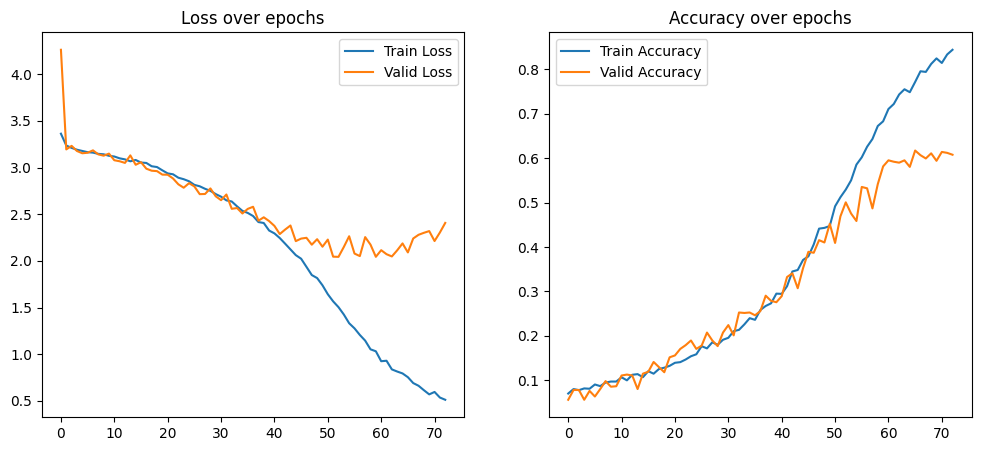

In [72]:
# 학습 및 검증 과정 시각화
plt.figure(figsize=(12, 5))
# 손실 시각화
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(valid_losses, label="Valid Loss")
plt.legend()
plt.title("Loss over epochs")

# 정확도 시각화
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(valid_accuracies, label="Valid Accuracy")
plt.legend()
plt.title("Accuracy over epochs")
# 그래프 출력
plt.show()

In [73]:
# 모델의 가중치만 저장하는 코드
torch.save(model.state_dict(), 'C:/Users/juril/데이터크리에이터캠프/final_model_weights.pth')
print("Model weights saved successfully.")

Model weights saved successfully.
